Model Değerlendirme

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error

# Veri yükleme
df = pd.read_csv("../resources/movie-rating-ds/ratings.csv")


print(df.shape)
print(df.head())



(100836, 4)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [4]:
df["user_prev_mean_rating"] = df.groupby("userId")["rating"].transform("mean")
df["user_prev_mean_rating"] = df["user_prev_mean_rating"].fillna(df["rating"].mean())


print(df.head())

   userId  movieId  rating  timestamp  user_prev_mean_rating
0       1        1     4.0  964982703               4.366379
1       1        3     4.0  964981247               4.366379
2       1        6     4.0  964982224               4.366379
3       1       47     5.0  964983815               4.366379
4       1       50     5.0  964982931               4.366379


In [ ]:
df["movie_prev_mean_rating"] = df.groupby("movieId")["rating"].transform("mean")
df["movie_prev_mean_rating"] = df["movie_prev_mean_rating"].fillna(df["rating"].mean())


print(df.head())

   userId  movieId  ...  user_prev_mean_rating  movie_prev_mean_rating
0       1        1  ...               4.366379                3.920930
1       1        3  ...               4.366379                3.259615
2       1        6  ...               4.366379                3.946078
3       1       47  ...               4.366379                3.975369
4       1       50  ...               4.366379                4.237745

[5 rows x 6 columns]


In [9]:
features = ["user_prev_mean_rating", "movie_prev_mean_rating", "userId", "movieId"]
target = "rating"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)



In [ ]:
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_mae = median_absolute_error(y_train, y_pred_train)
test_mae = median_absolute_error(y_test, y_pred_test)

metrics_df = pd.DataFrame({
    "R2": [train_r2, test_r2],
    "MSE": [train_mse, test_mse],
    "MAE": [train_mae, test_mae]
}, index=["Train", "Test"]) 

print(metrics_df)


             R2       MSE       MAE
Train  0.400481  0.649612  0.485877
Test   0.399857  0.660181  0.482665


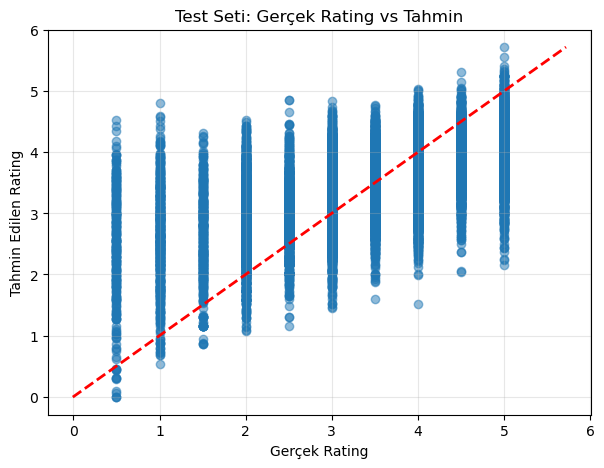

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.5)

line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())

plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)

plt.title("Test Seti: Gerçek Rating vs Tahmin")
plt.xlabel("Gerçek Rating")
plt.ylabel("Tahmin Edilen Rating")
plt.grid(alpha=0.3)
plt.show()

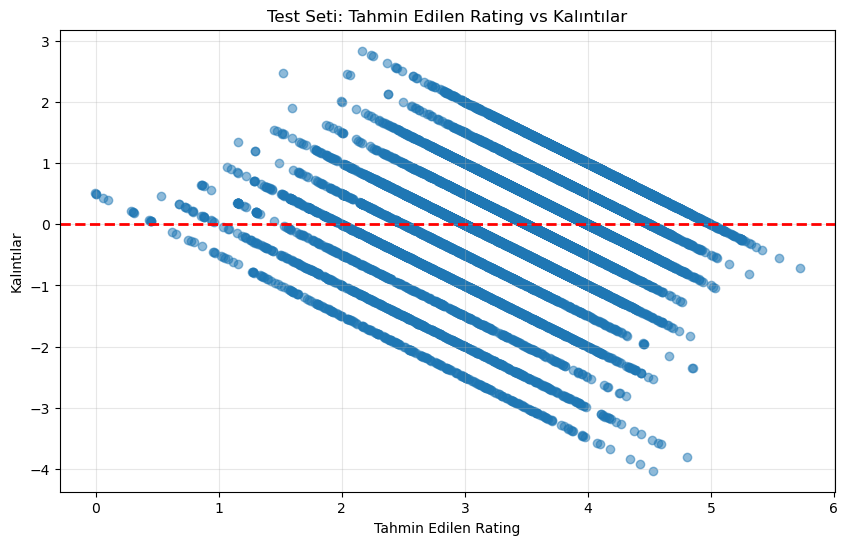

In [12]:
#residual

residuals = y_test - y_pred_test

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title("Test Seti: Tahmin Edilen Rating vs Kalıntılar")
plt.xlabel("Tahmin Edilen Rating")
plt.ylabel("Kalıntılar")
plt.grid(alpha=0.3)
plt.show()



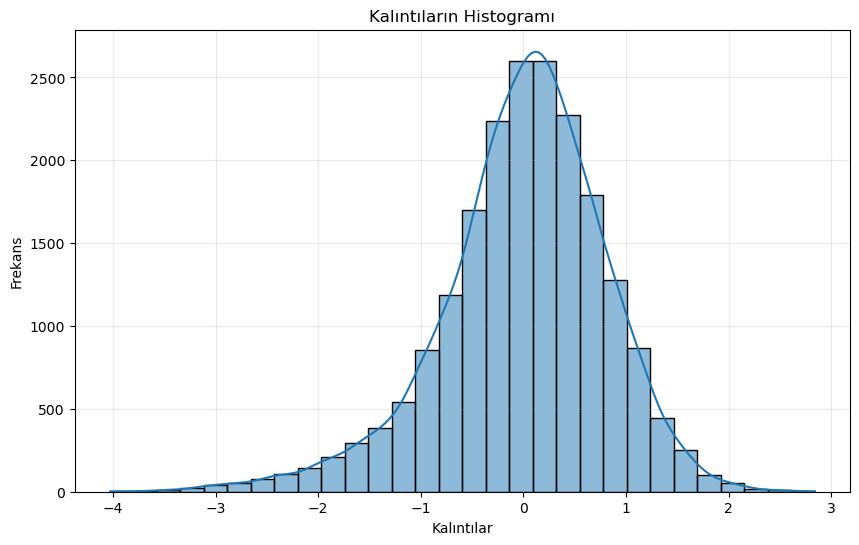

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Kalıntıların Histogramı")
plt.xlabel("Kalıntılar")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()
